In [43]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

In [44]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [45]:
# Root data directory path
data_dir = r"C:\Users\vinit\OneDrive\Desktop\Cancer Detection\notebook\data"

In [46]:
class_name=os.listdir(data_dir)
len(class_name)

2

In [47]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T, datasets

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:{}".format(device))

Device:cpu


In [49]:
data_transform = T.Compose([
    T.Resize(size=(224, 224)),  # Resizing the image to 224 x 224

    T.RandomRotation(degrees=(-20, +20)),  # Randomly rotate images by +/- 20 degrees

    T.ToTensor(),  # Convert image to tensor

    T.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [50]:
data=datasets.ImageFolder(data_dir,transform=data_transform)
total_count=len(data)

In [51]:
total_count

2641

In [52]:
data.classes

['full_forg', 'full_org']

In [53]:
# Splitting the data

train_count = int(0.6 * total_count)
valid_count = int(0.3 * total_count)
test_count = total_count - train_count - valid_count

train_data, val_data, test_data = torch.utils.data.random_split(data   ,   (train_count, valid_count, test_count))

In [54]:
train_data.dataset

Dataset ImageFolder
    Number of datapoints: 2641
    Root location: C:\Users\vinit\OneDrive\Desktop\Cancer Detection\notebook\data
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [55]:
def show_image(image, label, get_denormalize=True):

    image = image.permute(1, 2, 0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    if get_denormalize == True:
        image = image * std + mean
        image = np.clip(image, 0, 1)
        plt.imshow(image)
        plt.title(label)

    else:
        plt.imshow(image)
        plt.title(label)


def show_grid(image, title=None):

    image = image.permute(1, 2, 0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.figure(figsize=[15, 15])
    plt.imshow(image)

    if title != None:
        plt.title(title)

def accuracy(y_pred, y_true):
    y_pred = F.softmax(y_pred, dim=1)
    top_p, top_class = y_pred.topk(1, dim=1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

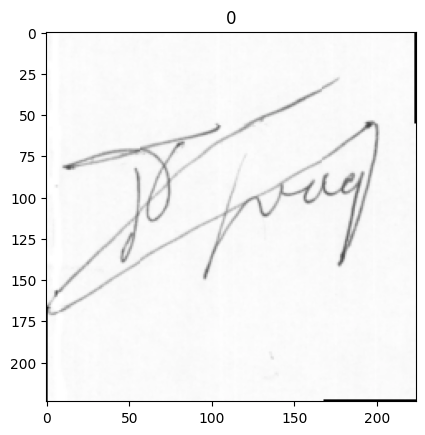

In [56]:
img , label=train_data[0]
show_image(img,label)

In [57]:
# Data Loaders!

trainloader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

print("No. of batches in trainloader: {}".format(len(trainloader)))
print("No. of Total examples: {}".format(len(trainloader.dataset)))


validationloader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=True
)

print("No. of batches in validationloader: {}".format(len(validationloader)))
print("No. of Total examples: {}".format(len(validationloader.dataset)))


testloader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

print("No. of batches in testloader: {}".format(len(testloader)))
print("No. of Total examples: {}".format(len(testloader.dataset)))

No. of batches in trainloader: 50
No. of Total examples: 1584
No. of batches in validationloader: 25
No. of Total examples: 792
No. of batches in testloader: 9
No. of Total examples: 265


In [58]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [59]:
model=models.resnet34(pretrained=True)

In [60]:
model.fc = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(model.fc.in_features, len(class_name))
)

model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-3,
    momentum=0.9
)

In [61]:
def train(model, criterion, optimizer, train_dataloader, test_dataloader):

    total_train_loss = 0
    total_test_loss = 0

    # Training
    model.train()

    with tqdm(train_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description('training')

        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            output = model(images)

            loss = criterion(output, idxs)
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

    # Testing
    model.eval()

    with torch.no_grad():
        with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
            pbar.set_description('testing')

            for images, idxs in pbar:
                images = images.to(device, non_blocking=True)
                idxs = idxs.to(device, non_blocking=True)

                output = model(images)

                loss = criterion(output, idxs)
                total_test_loss += loss.item()

    train_loss = total_train_loss / len(train_dataloader)
    test_loss = total_test_loss / len(test_dataloader)

    print(
        f'Train loss: {train_loss:.4f} '
        f'Test loss: {test_loss:.4f}'
    )

    return train_loss, test_loss

In [62]:
%%time

epochs = 5

for i in range(epochs):
    print(f"Epoch {i+1}/{epochs}")

    train(
        model,
        criterion,
        optimizer,
        trainloader,
        validationloader
    )

Epoch 1/5


Train loss: 0.2404 Test loss: 0.0861
Epoch 2/5


Train loss: 0.0378 Test loss: 0.0118
Epoch 3/5


Train loss: 0.0175 Test loss: 0.0166
Epoch 4/5


Train loss: 0.0199 Test loss: 0.3951
Epoch 5/5


Train loss: 0.0095 Test loss: 0.0285
CPU times: total: 1h 40min 8s
Wall time: 25min 27s


In [63]:
pwd

'C:\\Users\\vinit\\OneDrive\\Desktop\\Cancer Detection\\notebook'

In [64]:
path=r'C:\\Users\\vinit\\OneDrive\\Desktop\\Cancer Detection\\notebook\\model.pt'
torch.save(model,path)


In [65]:
model = torch.load(
    path,
    map_location=device,
    weights_only=False
)

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [66]:
def evaluate(model, criterion, optimizer, test_dataloader):
    total_test_loss = 0

    model.eval()

    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description('testing')

        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterion(output, idxs)

            total_test_loss += loss.item()

    test_acc = total_test_loss / len(val_data)

    print(f'Test loss: {test_acc:.10f}')

In [67]:
evaluate(model,criterion , optimizer ,testloader)
         

Test loss: 0.0003271267


In [68]:
label_names=data.classes
label_names

['full_forg', 'full_org']

In [69]:
from PIL import Image

# Load the image and preprocess it
image = Image.open(r'C:\Users\vinit\OneDrive\Desktop\Cancer Detection\notebook\data\full_org\original_1_4.png')

preprocess = transforms.Compose([ 
    transforms.Resize(size=(224, 224)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

image = preprocess(image)
image = image[:3]

# Convert the image to a PyTorch tensor and send it to the device
image = image.unsqueeze(0).to(device)

# Make the prediction
with torch.no_grad():
    logits = model(image)
    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)

# Print the prediction
print(f'Predicted label: {pred_label.item()}')

# Map the predicted label to the corresponding class name
predicted_class_name = label_names[pred_label.item()]

# Print the predicted class name
print(f'Predicted class name: {predicted_class_name}')

Predicted label: 0
Predicted class name: full_forg
